<a href="https://colab.research.google.com/github/RDRamosU/mercado-laboral-steam-cr/blob/main/notebooks/04_visualizaciones_hallazgos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 2 — Mercado Laboral Tech en Costa Rica
## Notebook 04 — Visualizaciones y hallazgos

**Autor:** Ruben Dario Ramos  
**Fecha:** Junio 2026  

---

## 1. Configuración del entorno

In [1]:
!pip install pdfplumber openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from google.colab import files
import os

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'

os.makedirs("assets/graficas", exist_ok=True)
print("Entorno configurado ✓")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 854.7 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 72.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.
Entorno configurado ✓


## 2. Carga y reconstrucción de datasets

In [2]:
# Subir archivo ECE
print("Selecciona el archivo ECE...")
uploaded = files.upload()
for nombre in uploaded.keys():
    nombre_ece = nombre

# Reconstruir df_ece
df_ece_raw = pd.read_excel(nombre_ece, sheet_name="Total",
                            header=None, engine='openpyxl')
fila_años = 4
year_row = df_ece_raw.iloc[fila_años]
año_a_col = {int(val): col_idx for col_idx, val in enumerate(year_row)
             if isinstance(val, (int, float)) and 2014 <= val <= 2025}

filas_indicadores = {
    'poblacion_total': 6, 'fuerza_trabajo': 17, 'ocupados': 18,
    'desempleados': 19, 'sector_comercio_servicios': 29,
    'ocup_calificada_alta': 33, 'educacion_universitaria': 61,
    'tasa_desempleo': 71, 'pct_subempleo': 78,
}
data = {'año': list(año_a_col.keys())}
for nombre, fila in filas_indicadores.items():
    data[nombre] = [df_ece_raw.iloc[fila, col] for col in año_a_col.values()]
df_ece = pd.DataFrame(data)
df_ece['pct_educacion_universitaria'] = (
    df_ece['educacion_universitaria'] / df_ece['ocupados'] * 100).round(1)

# Reconstruir df_empleo_tech
df_empleo_tech = pd.DataFrame({
    'año': [2020, 2021, 2022, 2023, 2024],
    'empleo_zf_servicios':  [90829,  101676, 117310, 116242, 119982],
    'empleo_zf_total':      [144202, 164212, 184035, 186658, 197038],
    'empleo_tic_formal':    [42902,  58910,  None,   None,   None],
    'salario_zf_usd':       [1686,   1566,   1640,   2075,   2319],
    'salario_nacional_usd': [1181,   1155,   1121,   1157,   1169],
})
df_empleo_tech['brecha_salarial'] = (
    df_empleo_tech['salario_zf_usd'] /
    df_empleo_tech['salario_nacional_usd']).round(2)

# Reconstruir df_radiografia
df_radiografia = pd.DataFrame({
    'disciplina': [
        'Ing. Software', 'Sistemas Info.', 'Tec. Información',
        'Ciencias Comp.', 'Ing. Computadores', 'Ing. Electrónica',
        'Ing. Industrial', 'Ing. Civil', 'Matemática'
    ],
    'desempleo_2019': [4.0, 4.6, 0.0, 1.1, 0.0, 2.3, 3.8, 2.1, 3.5],
})

# Reconstruir df_graduados
df_graduados = pd.DataFrame({
    'año': [2014,2015,2016,2017,2018,2019,2020,2021,2022],
    'steam_total':  [5169,5525,5711,6468,6154,6654,5830,7007,7273],
    'steam_mujer':  [2259,2445,2553,2836,2816,3049,2828,3246,3440],
    'steam_hombre': [2910,3080,3158,3632,3338,3605,3002,3761,3833],
})

# Dataset integrado
df_integrado = df_ece[df_ece['año'].isin([2020,2021,2022])][
    ['año','tasa_desempleo','educacion_universitaria',
     'ocup_calificada_alta']].merge(
    df_empleo_tech[['año','empleo_zf_servicios','empleo_zf_total',
                    'salario_zf_usd','salario_nacional_usd',
                    'brecha_salarial']], on='año').merge(
    df_graduados[df_graduados['año'].isin([2020,2021,2022])][
        ['año','steam_total','steam_mujer','steam_hombre']], on='año')
df_integrado['ratio_empleo_zf_vs_graduados'] = (
    df_integrado['empleo_zf_servicios'] /
    df_integrado['steam_total']).round(1)

print("Todos los datasets reconstruidos ✓")

Selecciona el archivo ECE...


Saving Principales+indicadores+EHPM+-+ECE+1987-2025+agrupado+Regiones+de+planficacin.xlsx to Principales+indicadores+EHPM+-+ECE+1987-2025+agrupado+Regiones+de+planficacin.xlsx
Todos los datasets reconstruidos ✓


## 3. Visualización 1 — Tasa de desempleo nacional 2014–2025

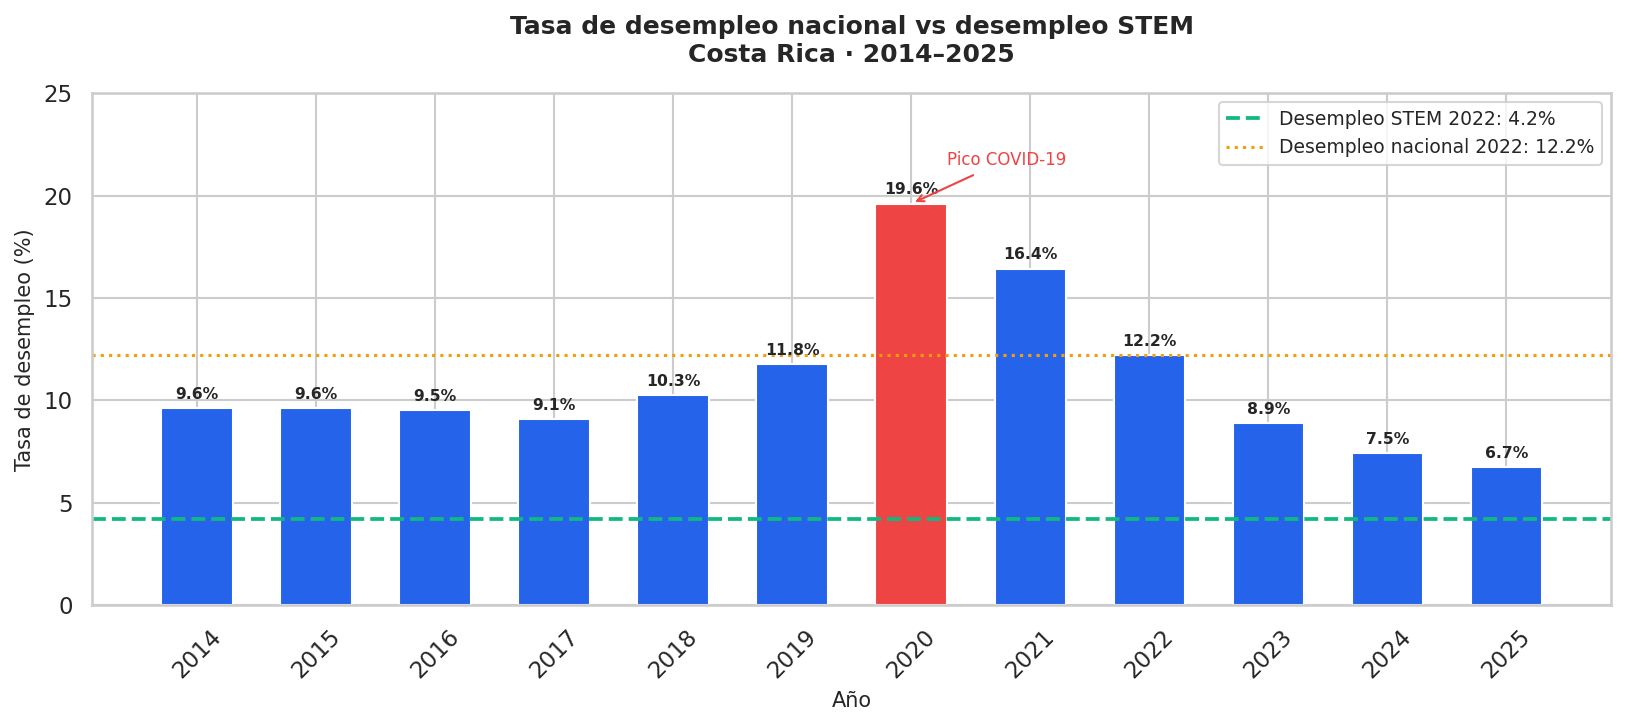

Gráfica 1 exportada ✓


In [3]:
fig, ax = plt.subplots(figsize=(11, 5))

colores = ['#EF4444' if año == 2020 else '#2563EB'
           for año in df_ece['año']]

bars = ax.bar(df_ece['año'], df_ece['tasa_desempleo'],
              color=colores, edgecolor='white', width=0.6)

for bar, val in zip(bars, df_ece['tasa_desempleo']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=7.5, fontweight='bold')

# Línea de desempleo STEM 2022
ax.axhline(y=4.2, color='#10B981', linestyle='--',
           linewidth=1.8, label='Desempleo STEM 2022: 4.2%')
ax.axhline(y=12.2, color='#F59E0B', linestyle=':',
           linewidth=1.5, label='Desempleo nacional 2022: 12.2%')

ax.annotate('Pico COVID-19', xy=(2020, 19.6),
            xytext=(2020.3, 21.5),
            arrowprops=dict(arrowstyle='->', color='#EF4444'),
            fontsize=8, color='#EF4444')

ax.set_title('Tasa de desempleo nacional vs desempleo STEM\n'
             'Costa Rica · 2014–2025',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Año', fontsize=10)
ax.set_ylabel('Tasa de desempleo (%)', fontsize=10)
ax.set_xticks(df_ece['año'])
ax.set_xticklabels(df_ece['año'], rotation=45)
ax.set_ylim(0, 25)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("assets/graficas/01_desempleo_nacional_vs_stem.png",
            bbox_inches='tight')
plt.show()
print("Gráfica 1 exportada ✓")

## 4. Visualización 2 — Desempleo por disciplina tech 2019

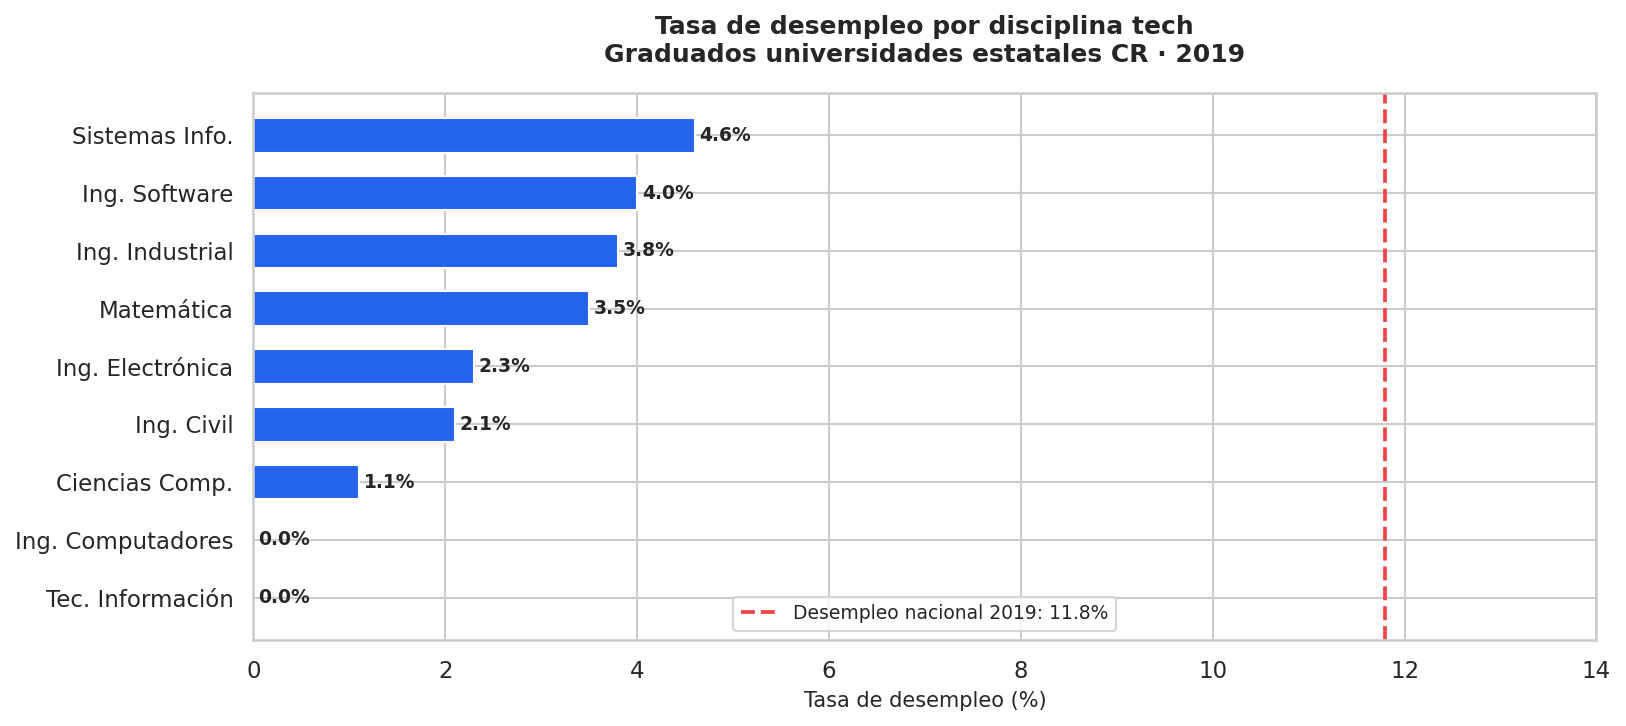

Gráfica 2 exportada ✓


In [4]:
fig, ax = plt.subplots(figsize=(11, 5))

df_rad_sorted = df_radiografia.sort_values('desempleo_2019', ascending=True)

colores_bar = ['#10B981' if v == 0.0 else '#2563EB'
               for v in df_rad_sorted['desempleo_2019']]

bars = ax.barh(df_rad_sorted['disciplina'],
               df_rad_sorted['desempleo_2019'],
               color=colores_bar, edgecolor='white', height=0.6)

for bar, val in zip(bars, df_rad_sorted['desempleo_2019']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

ax.axvline(x=11.8, color='#EF4444', linestyle='--',
           linewidth=1.8, label='Desempleo nacional 2019: 11.8%')

ax.set_title('Tasa de desempleo por disciplina tech\n'
             'Graduados universidades estatales CR · 2019',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Tasa de desempleo (%)', fontsize=10)
ax.set_xlim(0, 14)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("assets/graficas/02_desempleo_por_disciplina_tech.png",
            bbox_inches='tight')
plt.show()
print("Gráfica 2 exportada ✓")

## 5. Visualización 3 — Crecimiento del empleo tech vs graduados STEAM

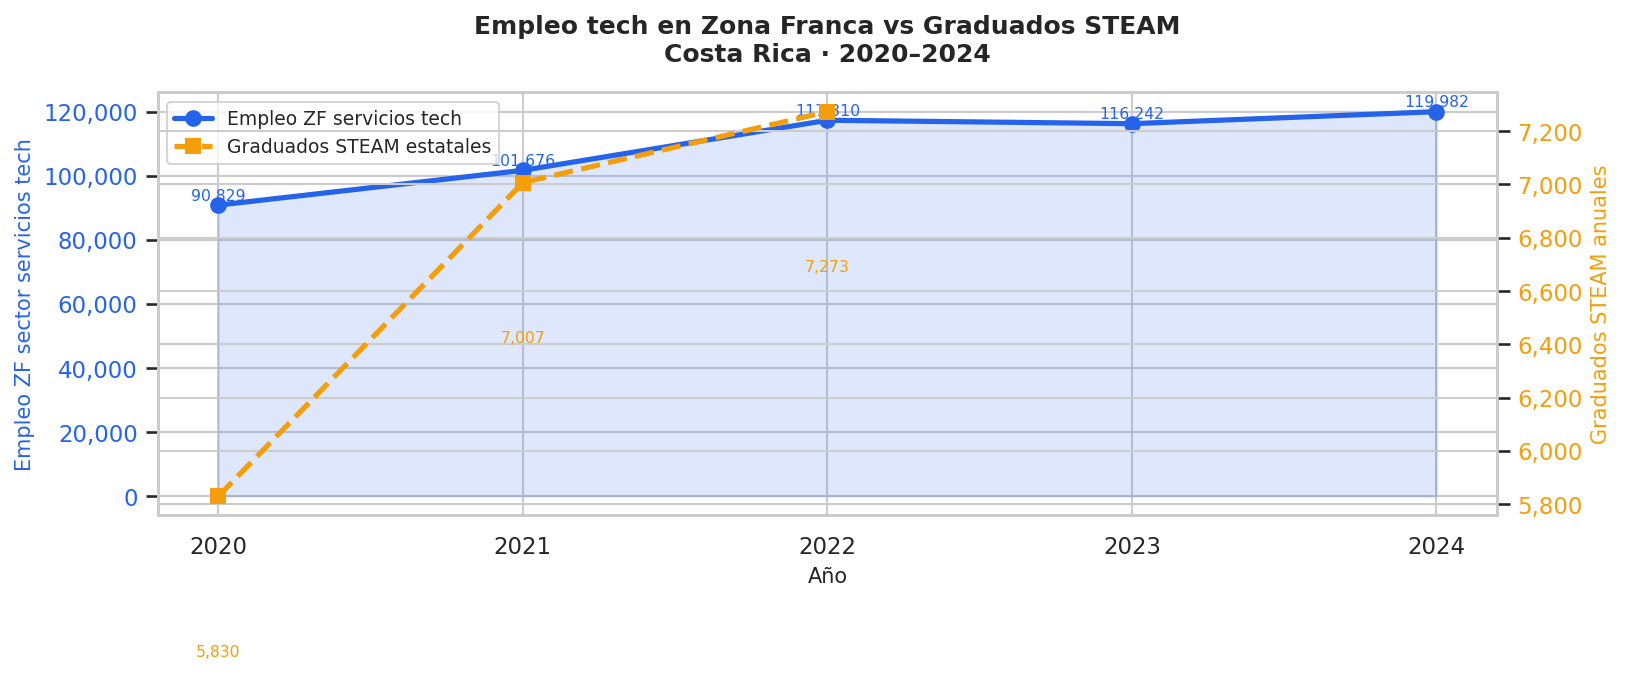

Gráfica 3 exportada ✓


In [5]:
fig, ax1 = plt.subplots(figsize=(11, 5))

# Eje izquierdo — empleo ZF servicios
ax1.fill_between(df_empleo_tech['año'],
                 df_empleo_tech['empleo_zf_servicios'],
                 alpha=0.15, color='#2563EB')
ax1.plot(df_empleo_tech['año'],
         df_empleo_tech['empleo_zf_servicios'],
         color='#2563EB', linewidth=2.5, marker='o',
         markersize=7, label='Empleo ZF servicios tech')

for x, y in zip(df_empleo_tech['año'],
                df_empleo_tech['empleo_zf_servicios']):
    ax1.text(x, y + 1500, f'{int(y):,}',
             ha='center', fontsize=7.5, color='#2563EB')

ax1.set_ylabel('Empleo ZF sector servicios tech', fontsize=10,
               color='#2563EB')
ax1.tick_params(axis='y', labelcolor='#2563EB')
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Eje derecho — graduados STEAM
ax2 = ax1.twinx()
df_grad_filtrado = df_graduados[df_graduados['año'].isin(
    df_empleo_tech['año'])]
ax2.plot(df_grad_filtrado['año'],
         df_grad_filtrado['steam_total'],
         color='#F59E0B', linewidth=2.5, marker='s',
         markersize=7, linestyle='--', label='Graduados STEAM estatales')

for x, y in zip(df_grad_filtrado['año'],
                df_grad_filtrado['steam_total']):
    ax2.text(x, y - 600, f'{int(y):,}',
             ha='center', fontsize=7.5, color='#F59E0B')

ax2.set_ylabel('Graduados STEAM anuales', fontsize=10,
               color='#F59E0B')
ax2.tick_params(axis='y', labelcolor='#F59E0B')
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax1.set_title('Empleo tech en Zona Franca vs Graduados STEAM\n'
              'Costa Rica · 2020–2024',
              fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel('Año', fontsize=10)
ax1.set_xticks(df_empleo_tech['año'])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig("assets/graficas/03_empleo_tech_vs_graduados.png",
            bbox_inches='tight')
plt.show()
print("Gráfica 3 exportada ✓")

## 6. Visualización 4 — Brecha salarial ZF vs promedio nacional

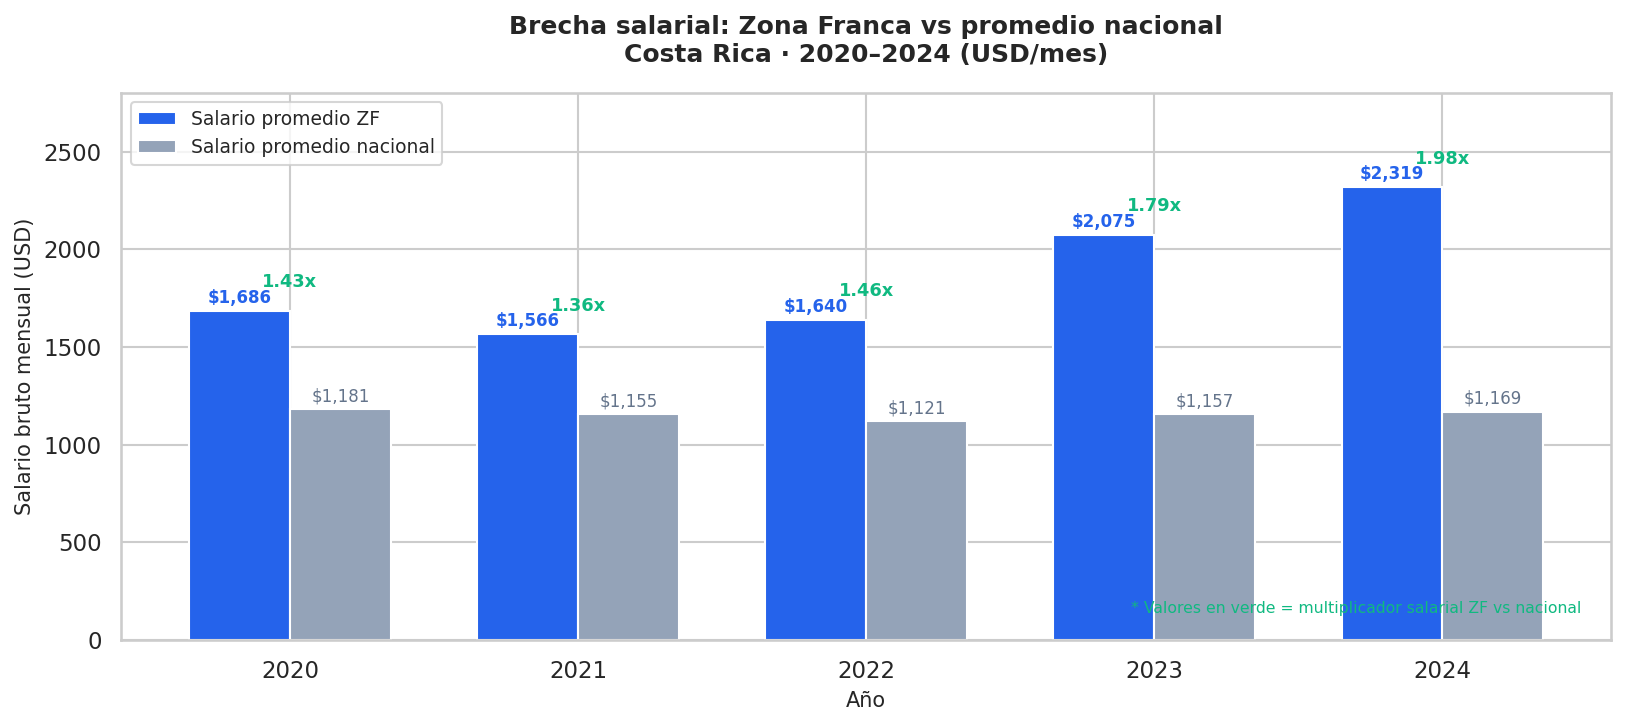

Gráfica 4 exportada ✓


In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(df_empleo_tech['año']))
ancho = 0.35

bars_zf = ax.bar(x - ancho/2, df_empleo_tech['salario_zf_usd'],
                 ancho, label='Salario promedio ZF',
                 color='#2563EB', edgecolor='white')
bars_nac = ax.bar(x + ancho/2, df_empleo_tech['salario_nacional_usd'],
                  ancho, label='Salario promedio nacional',
                  color='#94A3B8', edgecolor='white')

for bar, val in zip(bars_zf, df_empleo_tech['salario_zf_usd']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20,
            f'${int(val):,}', ha='center', va='bottom',
            fontsize=8, fontweight='bold', color='#2563EB')

for bar, val in zip(bars_nac, df_empleo_tech['salario_nacional_usd']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20,
            f'${int(val):,}', ha='center', va='bottom',
            fontsize=8, color='#64748B')

for i, (_, row) in enumerate(df_empleo_tech.iterrows()):
    ax.text(i, max(row['salario_zf_usd'],
                   row['salario_nacional_usd']) + 120,
            f'{row["brecha_salarial"]:.2f}x',
            ha='center', fontsize=8.5,
            fontweight='bold', color='#10B981')

ax.set_title('Brecha salarial: Zona Franca vs promedio nacional\n'
             'Costa Rica · 2020–2024 (USD/mes)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Año', fontsize=10)
ax.set_ylabel('Salario bruto mensual (USD)', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(df_empleo_tech['año'])
ax.set_ylim(0, 2800)
ax.legend(fontsize=9)
ax.text(0.98, 0.05, '* Valores en verde = multiplicador salarial ZF vs nacional',
        transform=ax.transAxes, fontsize=7.5,
        ha='right', color='#10B981')

plt.tight_layout()
plt.savefig("assets/graficas/04_brecha_salarial_zf_vs_nacional.png",
            bbox_inches='tight')
plt.show()
print("Gráfica 4 exportada ✓")

## 7. Hallazgos principales

In [7]:
print("=" * 58)
print("HALLAZGOS — MERCADO LABORAL TECH CR 2014–2025")
print("=" * 58)

# Hallazgo 1: brecha de desempleo
print(f"\n1. BRECHA DE DESEMPLEO STEM VS NACIONAL")
print(f"   Desempleo STEM 2022:     4.2%")
print(f"   Desempleo nacional 2022: 12.2%")
print(f"   Diferencia:              {12.2 - 4.2:.1f} puntos porcentuales")
print(f"   → El mercado absorbe casi todos los graduados tech")

# Hallazgo 2: ratio empleo vs graduados
print(f"\n2. RATIO EMPLEO ZF SERVICIOS TECH VS GRADUADOS STEAM")
for _, row in df_integrado.iterrows():
    print(f"   {int(row['año'])}: {int(row['empleo_zf_servicios']):,} empleos "
          f"/ {int(row['steam_total']):,} graduados "
          f"= {row['ratio_empleo_zf_vs_graduados']:.1f}x")
print(f"   → Por cada graduado STEAM hay ~15 empleos solo en ZF servicios")

# Hallazgo 3: brecha salarial
promedio_brecha = df_empleo_tech['brecha_salarial'].mean()
max_brecha = df_empleo_tech['brecha_salarial'].max()
print(f"\n3. BRECHA SALARIAL ZF VS NACIONAL")
print(f"   Promedio 2020-2024: {promedio_brecha:.2f}x más alto en ZF")
print(f"   Máximo (2024):      {max_brecha:.2f}x → USD 2.319 vs USD 1.169")

# Hallazgo 4: recuperación post-pandemia
print(f"\n4. RECUPERACIÓN POST-PANDEMIA")
desempleo_2020 = df_ece[df_ece['año']==2020]['tasa_desempleo'].values[0]
desempleo_2024 = df_ece[df_ece['año']==2024]['tasa_desempleo'].values[0]
print(f"   Tasa de desempleo 2020: {desempleo_2020:.1f}%")
print(f"   Tasa de desempleo 2024: {desempleo_2024:.1f}%")
print(f"   Reducción:              {desempleo_2020 - desempleo_2024:.1f} pp en 4 años")

print("\n" + "=" * 58)

HALLAZGOS — MERCADO LABORAL TECH CR 2014–2025

1. BRECHA DE DESEMPLEO STEM VS NACIONAL
   Desempleo STEM 2022:     4.2%
   Desempleo nacional 2022: 12.2%
   Diferencia:              8.0 puntos porcentuales
   → El mercado absorbe casi todos los graduados tech

2. RATIO EMPLEO ZF SERVICIOS TECH VS GRADUADOS STEAM
   2020: 90,829 empleos / 5,830 graduados = 15.6x
   2021: 101,676 empleos / 7,007 graduados = 14.5x
   2022: 117,310 empleos / 7,273 graduados = 16.1x
   → Por cada graduado STEAM hay ~15 empleos solo en ZF servicios

3. BRECHA SALARIAL ZF VS NACIONAL
   Promedio 2020-2024: 1.60x más alto en ZF
   Máximo (2024):      1.98x → USD 2.319 vs USD 1.169

4. RECUPERACIÓN POST-PANDEMIA
   Tasa de desempleo 2020: 19.6%
   Tasa de desempleo 2024: 7.5%
   Reducción:              12.2 pp en 4 años



## 8. Conclusiones

1. **La brecha es de escasez, no de exceso:** el desempleo STEM en 2022
   fue de 4.2% frente al 12.2% nacional. El mercado tech absorbe
   prácticamente todos los graduados disponibles.

2. **Desequilibrio estructural:** por cada graduado STEAM de universidades
   estatales existen entre 14.5 y 16.1 empleos solo en el sector servicios
   tech de Zona Franca. Sin contar empleo TIC formal ni empresas exportadoras.

3. **Incentivo salarial claro:** los empleados en Zona Franca ganan en
   promedio 1.98x más que el promedio nacional, llegando a 2x en 2024.
   Esto confirma la alta demanda y escasez de talento tech.

4. **Recuperación post-pandemia resiliente:** el sector tech mantuvo
   desempleo bajo incluso en 2020 (pico de 19.6% nacional), lo que
   demuestra su resiliencia frente a crisis económicas.

---
*Fuentes: CONARE-OPES · INEC ECE · MICITT · BCCR · PROCOMER*  
*Análisis: Ruben Dario Ramos Ulate · rubendario.dev*